# CartPole Environment - Deep Q-Network

### [CartPole Environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Volodymyr Mnih et al., https://arxiv.org/abs/1312.5602

[2] Gymnasium, https://gymnasium.farama.org/

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install -c conda-forge gymnasium
# conda install numpy matplotlib

## Import Libraries

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Parameters

In [5]:
STATE_DIM = 4
STATE_DIM

4

In [6]:
ACTION_DIM = 2
ACTION_DIM

2

In [7]:
HIDDEN_DIM = 128
HIDDEN_DIM

128

In [8]:
BUFFER_SIZE = 10000
BUFFER_SIZE

10000

## Hyperparameters

In [9]:
LEARNING_RATE = 0.001
LEARNING_RATE

0.001

In [10]:
EPISODES = 300
EPISODES

300

In [11]:
BATCH_SIZE = 64
BATCH_SIZE

64

In [12]:
GAMMA = 0.99
GAMMA

0.99

## Device

In [13]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Create Environment

In [14]:
env = gym.make('CartPole-v1')
state, _ = env.reset(seed=SEED)
print('state dim:', env.observation_space.shape[0])
print('action dim:', env.action_space.n)

state dim: 4
action dim: 2


## Create Replay Buffer

In [15]:
class ReplayBuffer:
    """
    A fixed-size experience replay buffer.
    """

    def __init__(self, capacity):
        """
        Initialize the buffer with a fixed capacity.

        Parameters:
            capacity (int): Maximum number of transitions.

        Returns:
            None
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """
        Store one transition.

        Parameters:
            state (np.ndarray): Current state.
            action (int): Action taken.
            reward (float): Reward received.
            next_state (np.ndarray): Next state.
            done (bool): Whether the episode ended.

        Returns:
            None
        """
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Sample a random batch of transitions.

        Parameters:
            batch_size (int): Number of transitions.

        Returns:
            tuple: Batched transitions.
        """
        batch = random.sample(self.buffer, batch_size)
        return zip(*batch)

    def __len__(self):
        """
        Return the number of stored transitions.

        Parameters:
            None

        Returns:
            int: Number of transitions.
        """
        return len(self.buffer)

## Create Q-Network

In [16]:
class QNetwork(nn.Module):
    """
    A small Q-network that scores each action.
    """

    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM, hidden=HIDDEN_DIM):
        """
        Initialize the network layers.

        Parameters:
            state_dim (int): Number of state features.
            action_dim (int): Number of actions.
            hidden (int): Hidden layer size.

        Returns:
            None
        """
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim))

    def forward(self, x):
        """
        Score every action for a batch of states.

        Parameters:
            x (torch.Tensor): Batch of states.

        Returns:
            torch.Tensor: Q-values per action.
        """
        return self.net(x)

## Instantiate Networks and Optimizer

In [17]:
torch.manual_seed(SEED)
policy = QNetwork().to(DEVICE)
target = QNetwork().to(DEVICE)
target.load_state_dict(policy.state_dict())
optimizer = torch.optim.Adam(policy.parameters(), lr=LEARNING_RATE)
buffer = ReplayBuffer(BUFFER_SIZE)
policy

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

## Train Model

### Functions

In [18]:
def to_tensor(array, dtype):
    """
    Convert a NumPy array to a tensor on the device.

    Parameters:
        array (np.ndarray): Input array.
        dtype (torch.dtype): Target dtype.

    Returns:
        torch.Tensor: Tensor on the device.
    """
    return torch.tensor(np.array(array), dtype=dtype, device=DEVICE)


def select_action(policy, state, epsilon, action_dim):
    """
    Choose an action with epsilon-greedy exploration.

    Parameters:
        policy (nn.Module): The Q-network.
        state (np.ndarray): Current state.
        epsilon (float): Exploration probability.
        action_dim (int): Number of actions.

    Returns:
        int: The chosen action.
    """
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state_tensor = to_tensor(state, torch.float32).unsqueeze(0)
        return int(policy(state_tensor).argmax(1).item())


def unpack_batch(buffer, batch_size):
    """
    Sample and convert a batch of transitions.

    Parameters:
        buffer (ReplayBuffer): The replay buffer.
        batch_size (int): Number of transitions.

    Returns:
        tuple: Converted tensors.
    """
    states, actions, rewards, next_states, dones = buffer.sample(batch_size)
    return (to_tensor(states, torch.float32),
            to_tensor(actions, torch.long),
            to_tensor(rewards, torch.float32),
            to_tensor(next_states, torch.float32),
            to_tensor(dones, torch.float32))


def dqn_loss(policy, target, states, actions, rewards, next_states, dones, gamma):
    """
    Compute the temporal-difference loss.

    Parameters:
        policy (nn.Module): The online network.
        target (nn.Module): The target network.
        states (torch.Tensor): Batch of states.
        actions (torch.Tensor): Batch of actions.
        rewards (torch.Tensor): Batch of rewards.
        next_states (torch.Tensor): Batch of next states.
        dones (torch.Tensor): Batch of done flags.
        gamma (float): Discount factor.

    Returns:
        torch.Tensor: The loss.
    """
    q_values = policy(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target(next_states).max(1).values
        targets = rewards + gamma * next_q * (1 - dones)
    return F.smooth_l1_loss(q_values, targets)


def optimize(policy, target, buffer, optimizer, batch_size, gamma):
    """
    Run one gradient step on a sampled batch.

    Parameters:
        policy (nn.Module): The online network.
        target (nn.Module): The target network.
        buffer (ReplayBuffer): The replay buffer.
        optimizer (torch.optim.Optimizer): Parameter update rule.
        batch_size (int): Number of transitions.
        gamma (float): Discount factor.

    Returns:
        float: The loss value.
    """
    batch = unpack_batch(buffer, batch_size)
    loss = dqn_loss(policy, target, *batch, gamma)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

### Training Loop

In [19]:
def train(env, policy, target, buffer, optimizer, episodes):
    """
    Train the agent over many episodes.

    Parameters:
        env (gym.Env): The environment.
        policy (nn.Module): The online network.
        target (nn.Module): The target network.
        buffer (ReplayBuffer): The replay buffer.
        optimizer (torch.optim.Optimizer): Parameter update rule.
        episodes (int): Number of episodes.

    Returns:
        list: Total reward per episode.
    """
    rewards_history = []
    epsilon = 1.0
    for episode in range(episodes):
        state, _ = env.reset(seed=episode)
        done = False
        total_reward = 0.0
        while not done:
            action = select_action(policy, state, epsilon, env.action_space.n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if len(buffer) >= BATCH_SIZE:
                optimize(policy, target, buffer, optimizer, BATCH_SIZE, GAMMA)
        epsilon = max(0.05, epsilon * 0.99)
        if episode % 10 == 0:
            target.load_state_dict(policy.state_dict())
        rewards_history.append(total_reward)
    return rewards_history

In [20]:
history = train(env, policy, target, buffer, optimizer, EPISODES)
print('last 20 mean reward:', np.mean(history[-20:]))

last 20 mean reward: 135.35


### Visualize Training

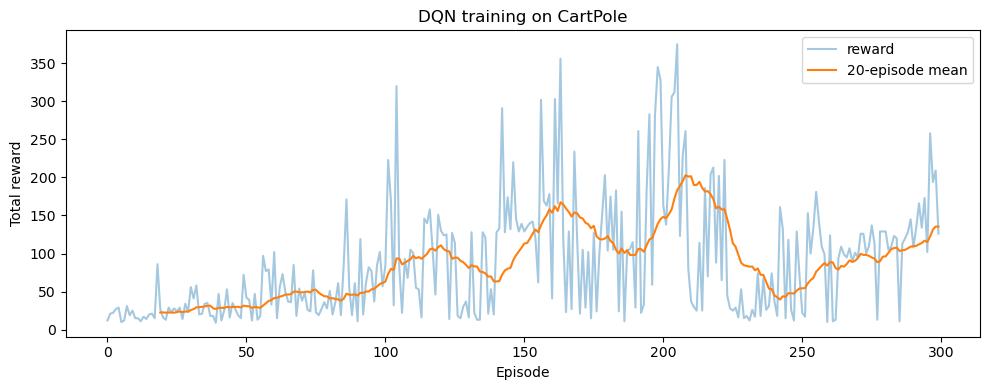

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(history, alpha=0.4, label='reward')
window = np.convolve(history, np.ones(20) / 20, mode='valid')
plt.plot(range(19, len(history)), window, label='20-episode mean')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('DQN training on CartPole')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate Model

### Function

In [22]:
def evaluate(policy, episodes=5):
    """
    Run the greedy policy and report mean reward.

    Parameters:
        policy (nn.Module): Trained network.
        episodes (int): Number of evaluation episodes.

    Returns:
        float: Mean reward.
    """
    policy.eval()
    env_eval = gym.make('CartPole-v1')
    rewards = []
    for episode in range(episodes):
        state, _ = env_eval.reset(seed=episode)
        done = False
        total = 0.0
        while not done:
            action = select_action(policy, state, 0.0, env_eval.action_space.n)
            state, reward, terminated, truncated, _ = env_eval.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    env_eval.close()
    return float(np.mean(rewards))

### Run

In [23]:
print(f"Mean evaluation reward: {evaluate(policy):.2f}")

Mean evaluation reward: 116.60


## Save Model

In [24]:
torch.save(policy.state_dict(), 'models/dqn_cartpole.pt')
print('saved dqn_cartpole.pt')

saved dqn_cartpole.pt


## Load Model

In [25]:
loaded_policy = QNetwork().to(DEVICE)
loaded_policy.load_state_dict(torch.load('models/dqn_cartpole.pt', map_location=DEVICE))
loaded_policy.eval()
print('loaded dqn_cartpole.pt')

loaded dqn_cartpole.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_81110/2762292527.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_policy.load_state_dict(torch.load('mod

## Inference

In [26]:
print(f"Mean evaluation reward: {evaluate(loaded_policy):.2f}")

Mean evaluation reward: 116.60
